# Deep Learning on Financial Data — A Step-by-Step Tutorial

**Goal:** teach you what deep learning *is* by building a small one end-to-end, on
financial market data, with no prior knowledge assumed.

By the end of this notebook you will have:

1. Turned a stream of stock prices into a **supervised learning problem**.
2. Built a small **neural network from scratch** in plain NumPy — so you can see every
   number that moves. No magic.
3. Understood the four ideas that make deep learning work: the **forward pass**, a
   **loss function**, **backpropagation**, and **gradient descent**.
4. **Trained** the network and **evaluated** it honestly against simple baselines.
5. Rebuilt the same model in **PyTorch** to see what a real framework does for you.
6. Run a toy **backtest** — and learned why beating the market is *much* harder than
   beating a baseline.

### The one mental model to keep

> A neural network is just a **function with adjustable knobs**. We show it examples of
> *input → correct answer*, measure how wrong it is with a single number (the *loss*),
> and nudge every knob a tiny bit in the direction that reduces that number. Repeat
> thousands of times. That repeated nudging *is* "learning".

### How to use this notebook
Run the cells **in order**, top to bottom (`Shift+Enter`). Each code cell is heavily
commented; read the markdown first, then the code. The core only needs `numpy`,
`pandas`, and `matplotlib`. The PyTorch section is optional and is skipped automatically
if PyTorch is not installed.

> **Reality check up front:** real markets are extremely close to *unpredictable* from
> price history alone. To make the learning visible we generate **synthetic** data with
> a deliberately planted (and unrealistically strong) pattern. This notebook teaches
> deep learning mechanics — it is **not** trading advice and the model is **not**
> expected to make money on real markets. We will return to this honesty at the end.

## Step 1 — Setup

We import three libraries:

- **NumPy** — fast arrays and math. A neural network is mostly matrix multiplications,
  and NumPy is how we do them. This is the only tool we need to build the network itself.
- **pandas** — tables (`DataFrame`s) with labelled columns and a date index. Great for
  holding a price series and computing things like daily returns.
- **matplotlib** — plots, so we can *see* the data and the training progress.

We also fix a **random seed**. Many steps use randomness (generating data, initial values
of the network's knobs). Fixing the seed makes every run identical, so your numbers will
match these and results are reproducible.

In [9]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# A "seed" makes the (pseudo) random number generator deterministic.
# Same seed -> same "random" numbers every run -> reproducible results.
SEED = 42
rng = np.random.default_rng(SEED)   # a modern NumPy random generator we will reuse

# Make plots a sensible default size.
plt.rcParams["figure.figsize"] = (10, 4)

print("Libraries imported. NumPy version:", np.__version__)

Libraries imported. NumPy version: 2.4.6


## Step 2 — Get some data

A neural network learns from **examples**, so first we need data. We use a synthetic
**daily price series** for one imaginary stock.

### Why synthetic instead of a real stock?
- It always works offline — no API keys, no rate limits, no missing-data surprises.
- We *control the pattern* hidden in it, so we can confirm the network actually learns
  something (on real data you never know if a pattern even exists).

### How the data is generated (the important idea: *returns*)
We do **not** model the price directly. We model the daily **return** — the percentage
change from one day to the next — because that is what actually matters in finance and
what models can hope to predict.

We use a simple rule called an **AR(1)** process ("auto-regressive, order 1"):

```
return_today = drift + phi * return_yesterday + noise
```

- `drift` is a tiny upward tendency (markets tend to rise over time).
- `phi` ("momentum") makes today's return lean in the same direction as yesterday's.
  This is the **pattern we plant** for the network to discover. We set it
  unrealistically high (0.30) so learning is clearly visible.
- `noise` is random unpredictability — the part nothing can forecast. In real markets,
  noise dominates and `phi` is ~0.

Finally we turn returns back into a **price** by compounding them, starting at \$100.

Generated 2500 trading days, from 2000-01-03 to 2009-07-31


,price,return
2000-01-03,98.720123,-0.012799
2000-01-04,99.535817,0.008263
2000-01-05,98.994164,-0.005442
2000-01-06,100.438905,0.014594
2000-01-07,101.435387,0.009921


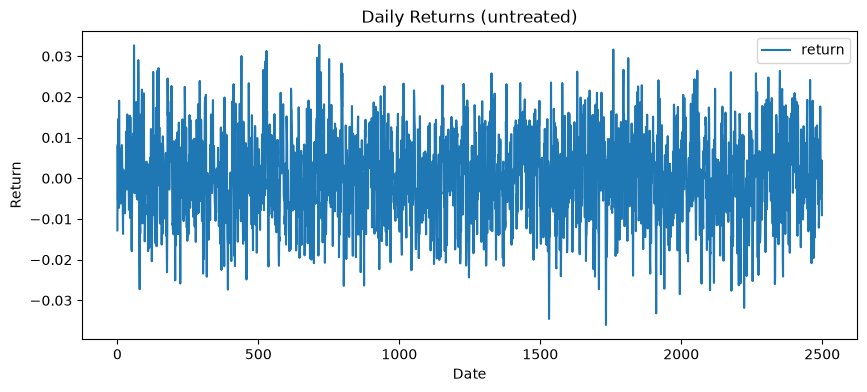

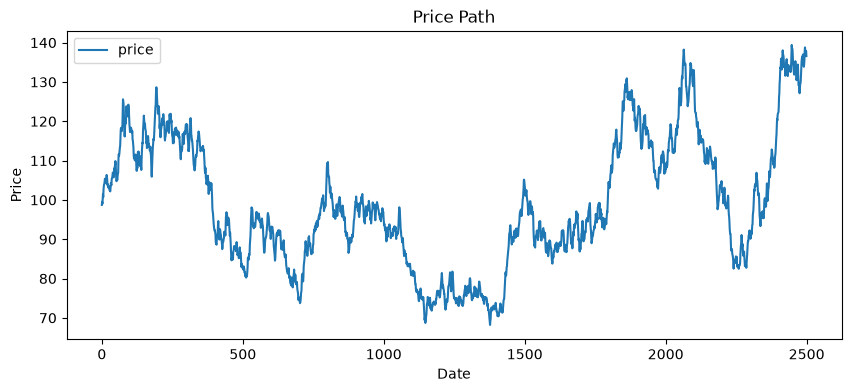

In [31]:
def generate_prices(n_days=2500, drift=0.0003, phi=0.30, vol=0.01, start_price=100.0, rng=rng):
    """Create a synthetic daily price series with planted 'momentum'.

    Parameters
    ----------
    n_days     : how many trading days to simulate (~10 years of ~250 days/yr).
    drift      : small constant added each day -> gentle long-term upward trend.
    phi        : momentum. How much yesterday's return carries into today.
                 This is the learnable signal. Real markets: ~0. Here: 0.30 (easy mode).
    vol        : size of the daily random shock (volatility). ~1% is realistic.
    start_price: the price on day 0.
    rng        : a NumPy random number generator (for reproducibility).
    Returns
    -------
    A pandas DataFrame indexed by date, with columns 'price' and 'return'.
    """
    returns = np.zeros(n_days)          # will hold each day's return
    prev = 0.0                          # yesterday's return; 0 before day 0
    for t in range(n_days):
        shock = rng.normal(0.0, vol)    # the unpredictable part (Gaussian noise)
        r = drift + phi * prev + shock  # the AR(1) rule
        returns[t] = r
        prev = r                        # today becomes "yesterday" for the next step
    pd.DataFrame({"return": returns}).plot(title="Daily Returns (untreated)", ylabel="Return", xlabel="Date")
    # Compound the returns into a price path: price_t = price_0 * prod(1 + r_i).
    prices = start_price * np.cumprod(1.0 + returns)
    pd.DataFrame({"price": prices}).plot(title="Price Path", ylabel="Price", xlabel="Date")
    # Give it a realistic-looking business-day date index (weekdays only).
    dates = pd.bdate_range(start="2000-01-01", periods=n_days)
    df = pd.DataFrame({"price": prices, "return": returns}, index=dates)
    return df

df = generate_prices()
print(f"Generated {len(df)} trading days, from {df.index[0].date()} to {df.index[-1].date()}")
df.head()

> **Optional — using a real stock instead.** If you have internet and `pip install yfinance`,
> you can replace the synthetic data. Everything downstream still works because we only
> rely on the `price` column. Just expect the model to perform near chance — real price
> history has almost no exploitable pattern. (Cell left as a comment so the notebook runs
> offline by default.)

In [11]:
# import yfinance as yf
# raw = yf.download("AAPL", start="2014-01-01", end="2024-01-01", auto_adjust=True)
# df = pd.DataFrame({"price": raw["Close"].squeeze()})
# df["return"] = df["price"].pct_change().fillna(0.0)
# df.head()

## Step 3 — Look at the data first (always)

Before modelling, *look*. Plotting catches mistakes and builds intuition. We plot:

1. The **price** over time — should drift upward and wander like a stock.
2. The **daily returns** — should hover around zero with occasional spikes.

We also check the **base rate**: what fraction of days were "up" (positive return)?
This is the number any model must beat. If 52% of days are up, a lazy "always predict up"
rule already gets 52% accuracy — so 52% is our bar, not 0%.

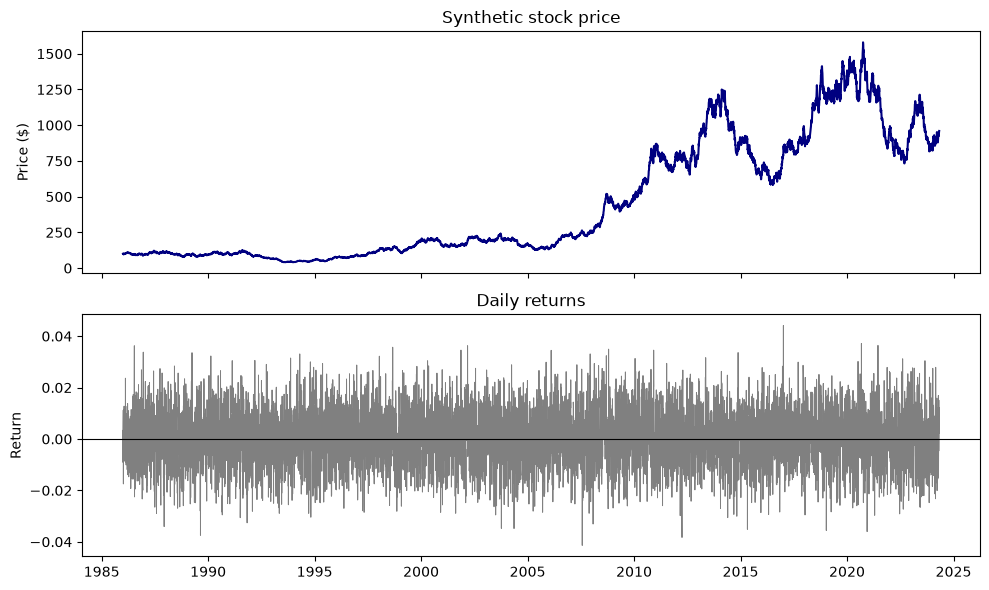

Fraction of 'up' days (base rate): 0.508
=> 'always predict up' scores about 50.8% accuracy. That is the number to beat.


In [12]:
fig, ax = plt.subplots(2, 1, figsize=(10, 6), sharex=True)

ax[0].plot(df.index, df["price"], color="navy")
ax[0].set_title("Synthetic stock price")
ax[0].set_ylabel("Price ($)")

ax[1].plot(df.index, df["return"], color="gray", linewidth=0.7)
ax[1].axhline(0, color="black", linewidth=0.8)
ax[1].set_title("Daily returns")
ax[1].set_ylabel("Return")
plt.tight_layout()
plt.show()

up_fraction = (df["return"] > 0).mean()
print(f"Fraction of 'up' days (base rate): {up_fraction:.3f}")
print(f"=> 'always predict up' scores about {max(up_fraction, 1-up_fraction):.1%} accuracy. That is the number to beat.")

## Step 4 — Turn the data into a learning problem

A neural network does **supervised learning**: it learns a mapping from an **input** `X`
to a **target** `y`, using many `(X, y)` example pairs. So we must define both.

### The target `y` — what we predict
We predict **direction**: will *tomorrow's* return be positive?
- `y = 1` if tomorrow's return > 0 (an "up" day)
- `y = 0` otherwise

Predicting a yes/no label like this is called **binary classification**.

### The input `X` — what the model gets to look at
For each day we build a feature vector from the **past `WINDOW` daily returns**
(here, the last 10). The intuition: if there is momentum, recent returns should hint at
the next one. This sliding-window trick is how you feed *sequence* data to a plain network.

### The cardinal rule: no peeking into the future (no "look-ahead leakage")
Every feature for predicting day `t+1` must come **only** from days `<= t`. If even one
future value sneaks into the inputs, the model "cheats", scores beautifully here, and
fails completely in real use. We build the windows carefully so this never happens.

In [13]:
WINDOW = 10   # how many past days of returns the model sees for each prediction

returns = df["return"].to_numpy()

# Build examples with a sliding window.
# For each day t (with at least WINDOW days of history before it AND a day t+1 to predict),
#   input  = returns[t-WINDOW : t]        <- the 10 days ending YESTERDAY (no future info)
#   target = 1 if returns[t] > 0 else 0   <- did TODAY (the next day) go up?
X_list, y_list = [], []
for t in range(WINDOW, len(returns)):
    X_list.append(returns[t - WINDOW:t])   # past 10 returns, strictly before day t
    y_list.append(1.0 if returns[t] > 0 else 0.0)

X = np.array(X_list)                 # shape (num_examples, WINDOW)
y = np.array(y_list).reshape(-1, 1)  # shape (num_examples, 1); column vector is handy later

print("X shape:", X.shape, "  (rows = examples, columns = the 10 input features)")
print("y shape:", y.shape, "  (one 0/1 label per example)")
print("\nFirst example input (10 past returns):\n", np.round(X[0], 4))
print("Its label (did the next day go up?):", int(y[0, 0]))

X shape: (9990, 10)   (rows = examples, columns = the 10 input features)
y shape: (9990, 1)   (one 0/1 label per example)

First example input (10 past returns):
 [ 0.0033 -0.0091  0.0051  0.0112 -0.0158 -0.0175 -0.0037 -0.004  -0.0011
 -0.0085]
Its label (did the next day go up?): 1


## Step 5 — Split the data the *time-aware* way, then scale it

### Why split at all?
We must measure the model on data it has **never seen**, otherwise we are just testing its
memory. So we carve the data into three chronological blocks:

- **Train (70%)** — the model learns its knobs from these.
- **Validation (15%)** — a "practice exam" during training, to watch for overfitting.
- **Test (15%)** — the final, untouched exam, looked at **once** at the very end.

### Why chronological (not random)?
With time series you must train on the **past** and test on the **future**. A random split
would let the model train on days *surrounding* a test day — another form of leakage.
So we slice by time: earliest days train, latest days test.

### Why scale the features?
Neural networks train far better when inputs are on a similar, modest scale (roughly mean 0,
spread 1). We **standardize**: subtract the mean and divide by the standard deviation.

Crucial detail: we compute that mean and std on the **training set only**, then apply the
*same* numbers to validation and test. Using test statistics would leak information about
the future into our preprocessing.

In [14]:
n = len(X)
i_train = int(n * 0.70)
i_val   = int(n * 0.85)

X_train, y_train = X[:i_train],        y[:i_train]
X_val,   y_val   = X[i_train:i_val],   y[i_train:i_val]
X_test,  y_test  = X[i_val:],          y[i_val:]

print(f"Train: {len(X_train)} examples | Val: {len(X_val)} | Test: {len(X_test)}")

# Standardize using TRAIN statistics only (no leakage).
mu    = X_train.mean(axis=0)            # per-feature mean,  shape (WINDOW,)
sigma = X_train.std(axis=0) + 1e-8      # per-feature std; +tiny number avoids divide-by-zero

X_train = (X_train - mu) / sigma
X_val   = (X_val   - mu) / sigma        # same mu/sigma applied to val...
X_test  = (X_test  - mu) / sigma        # ...and test

print("\nAfter scaling, training features have ~0 mean and ~1 std:")
print("mean ~", np.round(X_train.mean(), 4), " std ~", np.round(X_train.std(), 4))

Train: 6993 examples | Val: 1498 | Test: 1499

After scaling, training features have ~0 mean and ~1 std:
mean ~ 0.0  std ~ 1.0


## Step 6 — What *is* a neural network? (the concepts)

Now the heart of it. Read this slowly; the code in the next steps implements exactly this.

### A single neuron
A neuron takes several inputs `x1..xn`, multiplies each by a **weight** `w`, adds them up,
adds a **bias** `b`, and passes the result through an **activation function**:

```
output = activation( w1*x1 + w2*x2 + ... + wn*xn + b )
```

The weights and bias are the **knobs** ("parameters"). Learning = finding good values for them.

### Why the activation function?
Without it, stacking neurons would still only ever produce straight-line (linear)
relationships. The activation adds a **bend**, letting the network represent curved,
complex patterns. We use **ReLU** ("rectified linear unit") in the hidden layer — it simply
keeps positive values and zeroes out negatives: `relu(z) = max(0, z)`. Simple and effective.

### Layers and "deep"
We arrange neurons in **layers**. Our network:

```
   10 inputs  ->  [ hidden layer: 16 neurons + ReLU ]  ->  [ 1 output neuron + sigmoid ]  ->  probability
```

"**Deep** learning" just means a network with one or more hidden layers between input and
output. Ours has one hidden layer — small, but genuinely a (shallow) deep net. Stacking
more layers is the same idea repeated.

### The output: a probability
The final neuron uses a **sigmoid** activation, which squashes any number into the range
`(0, 1)`. We read that as **"probability the next day is up."** Above 0.5 → predict up.

### The four moving parts (the whole game)
1. **Forward pass** — push inputs through the layers to get a prediction.
2. **Loss** — one number measuring how wrong the predictions are vs. the true labels.
3. **Backpropagation** — compute how each knob affects the loss (its *gradient*).
4. **Gradient descent** — nudge every knob slightly to reduce the loss. Repeat.

We implement each next, in plain NumPy.

## Step 7 — The building-block functions

Two activation functions and the loss. We define them as plain functions so you can see the
exact math — there is nothing hidden.

- **sigmoid(z) = 1 / (1 + e^-z)** — squashes to (0, 1) for the output probability.
- **relu(z) = max(0, z)** — the hidden-layer bend.
- **Binary cross-entropy (BCE)** loss — the standard "how wrong are these probabilities"
  score for yes/no problems. If the true label is 1, it is `-log(p)`; if 0, it is
  `-log(1-p)`. Confident-and-right → tiny loss; confident-and-wrong → huge loss. We average
  over all examples to get a single number.

In [15]:
def sigmoid(z):
    # Squash any real number into (0, 1). clip avoids overflow warnings for big |z|.
    return 1.0 / (1.0 + np.exp(-np.clip(z, -500, 500)))

def relu(z):
    # Keep positives, zero out negatives. The network's source of non-linearity.
    return np.maximum(0.0, z)

def bce_loss(y_true, y_pred):
    # Binary cross-entropy, averaged over all examples -> a single "how wrong" number.
    eps = 1e-9  # keeps log() away from log(0) = -infinity
    p = np.clip(y_pred, eps, 1 - eps)
    return -np.mean(y_true * np.log(p) + (1 - y_true) * np.log(1 - p))

# Quick sanity checks so the ideas feel concrete:
print("sigmoid(0) =", sigmoid(np.array([0.0]))[0], " (0 maps to exactly 0.5)")
print("relu(-3, 2) =", relu(np.array([-3.0, 2.0])))
print("loss when confident & RIGHT  (true=1, pred=0.99):", round(bce_loss(np.array([1.0]), np.array([0.99])), 4))
print("loss when confident & WRONG  (true=1, pred=0.01):", round(bce_loss(np.array([1.0]), np.array([0.01])), 4))

sigmoid(0) = 0.5  (0 maps to exactly 0.5)
relu(-3, 2) = [0. 2.]
loss when confident & RIGHT  (true=1, pred=0.99): 0.0101
loss when confident & WRONG  (true=1, pred=0.01): 4.6052


## Step 8 — Create the network (initialize the knobs)

Our network has two layers of parameters:

- **Layer 1 (hidden):** weights `W1` of shape `(10, 16)` and biases `b1` of shape `(1, 16)`
  — turning 10 inputs into 16 hidden values.
- **Layer 2 (output):** weights `W2` of shape `(16, 1)` and biases `b2` of shape `(1, 1)`
  — turning 16 hidden values into 1 number.

### Why random (and why *this* random)?
We must start the weights somewhere. We start **random** so different neurons learn
different things (if they all started identical, they would stay identical forever — they
would have no reason to differ). We scale the randomness using **He initialization**
(`* sqrt(2 / fan_in)`), a recipe that keeps the signal from exploding or vanishing as it
passes through ReLU layers — it just makes training more stable. Biases start at 0.

In [16]:
def init_network(n_inputs=WINDOW, n_hidden=16, rng=rng):
    """Create the starting parameters (the 'knobs'). Returns a dict of arrays."""
    params = {
        # He init: random normal scaled by sqrt(2 / number_of_inputs_to_the_layer).
        "W1": rng.normal(0, np.sqrt(2.0 / n_inputs),  size=(n_inputs, n_hidden)),
        "b1": np.zeros((1, n_hidden)),
        "W2": rng.normal(0, np.sqrt(2.0 / n_hidden), size=(n_hidden, 1)),
        "b2": np.zeros((1, 1)),
    }
    return params

params = init_network()
for name, arr in params.items():
    print(f"{name}: shape {arr.shape}")
total = sum(a.size for a in params.values())
print(f"\nTotal learnable parameters (knobs): {total}")

W1: shape (10, 16)
b1: shape (1, 16)
W2: shape (16, 1)
b2: shape (1, 1)

Total learnable parameters (knobs): 193


## Step 9 — The forward pass (make a prediction)

The forward pass pushes inputs through the layers to produce predictions. With matrices we
do it for **all examples at once** (each row of `X` is one example):

```
z1 = X  @ W1 + b1      # weighted sums into the hidden layer        (examples x 16)
a1 = relu(z1)          # hidden activations (apply the bend)        (examples x 16)
z2 = a1 @ W2 + b2      # weighted sum into the output neuron        (examples x 1)
p  = sigmoid(z2)       # squash to a probability in (0, 1)          (examples x 1)
```

`@` is matrix multiplication. That is the *entire* prediction machine. We also return the
intermediate values (`z1, a1, ...`) in a "cache" because backpropagation will need them.

In [17]:
def forward(params, X):
    """Run inputs X through the network. Returns predictions p and a cache for backprop."""
    z1 = X @ params["W1"] + params["b1"]   # linear combo into hidden layer
    a1 = relu(z1)                          # hidden activations
    z2 = a1 @ params["W2"] + params["b2"]  # linear combo into output
    p  = sigmoid(z2)                       # output probabilities (next-day-up)

    cache = {"X": X, "z1": z1, "a1": a1, "z2": z2, "p": p}
    return p, cache

# Try it with the untrained (random) network. Predictions will be near 0.5 = "no idea yet".
p0, _ = forward(params, X_train)
print("Predicted probabilities for first 5 training days:", np.round(p0[:5, 0], 3))
print("Starting training loss:", round(bce_loss(y_train, p0), 4))

Predicted probabilities for first 5 training days: [0.3   0.283 0.04  0.129 0.171]
Starting training loss: 1.0721


## Step 10 — Backpropagation and gradient descent (the actual *learning*)

We have predictions and a loss. Now: **how should each knob change to make the loss smaller?**

### Gradient = slope = direction of steepest increase
For each parameter, its **gradient** is how much the loss would rise if we nudged that
parameter up a hair. To *decrease* the loss we step in the **opposite** direction. That is
**gradient descent**:

```
parameter <- parameter - learning_rate * gradient
```

The **learning rate** is the step size: too big and we overshoot/diverge; too small and
learning crawls.

### Backpropagation = the chain rule, layer by layer
**Backprop** is just an efficient way to compute every gradient. It applies calculus's
**chain rule** from the loss backward through the layers, reusing the cached values. You do
not need to derive it by hand — but here is the clean result for our network (a famous
simplification: combining sigmoid with BCE makes the first gradient just `p - y`):

```
dz2 = (p - y) / N           # gradient at the output    (N x 1)
dW2 = a1.T @ dz2            # gradient for W2            (16 x 1)
db2 = sum(dz2)             # gradient for b2

da1 = dz2 @ W2.T           # push gradient back into hidden layer
dz1 = da1 * (z1 > 0)       # ReLU's gradient: pass through where input was positive, else 0
dW1 = X.T @ dz1            # gradient for W1            (10 x 16)
db1 = sum(dz1)            # gradient for b1
```

`N` is the number of examples (we average). Read it as: the error at the output
(`p - y`) gets distributed backward to every knob according to how much that knob
contributed. That distribution *is* learning.

In [18]:
def backward(params, cache, y_true):
    """Backpropagation: compute the gradient of the loss w.r.t. every parameter."""
    X, z1, a1, p = cache["X"], cache["z1"], cache["a1"], cache["p"]
    N = X.shape[0]   # number of examples; we average the gradient over them

    # --- output layer ---
    # The neat sigmoid+BCE result: gradient of loss w.r.t. z2 is simply (p - y)/N.
    dz2 = (p - y_true) / N                 # (N, 1)
    dW2 = a1.T @ dz2                       # (16, 1)
    db2 = dz2.sum(axis=0, keepdims=True)   # (1, 1)

    # --- hidden layer (chain rule back through W2 and ReLU) ---
    da1 = dz2 @ params["W2"].T             # (N, 16)
    dz1 = da1 * (z1 > 0)                   # ReLU gradient: 1 where z1>0, else 0
    dW1 = X.T @ dz1                        # (10, 16)
    db1 = dz1.sum(axis=0, keepdims=True)   # (1, 16)

    return {"W1": dW1, "b1": db1, "W2": dW2, "b2": db2}

def sgd_step(params, grads, learning_rate):
    """Gradient descent: nudge every parameter opposite to its gradient."""
    for key in params:
        params[key] -= learning_rate * grads[key]
    return params

print("Backward pass and update step defined. These two functions are where learning happens.")

Backward pass and update step defined. These two functions are where learning happens.


## Step 11 — The training loop

Now we just repeat the cycle many times. One full pass over the training data is an
**epoch**. Each epoch we:

1. **Forward** — predict on the training set.
2. **Loss** — measure how wrong we are.
3. **Backward** — compute gradients (backprop).
4. **Update** — nudge the knobs (gradient descent).

After each epoch we also measure the loss on the **validation** set — data we do *not* train
on. Watching train-loss vs. val-loss tells us whether we are genuinely learning
(both fall) or just **overfitting** (train falls but val rises — memorizing noise).

We keep the network small and the run short; it trains in a second or two.

In [19]:
def accuracy(params, X, y_true):
    """Fraction of correct up/down predictions (probability > 0.5 means 'up')."""
    p, _ = forward(params, X)
    predicted_label = (p > 0.5).astype(float)
    return np.mean(predicted_label == y_true)

# Fresh network so re-running this cell always starts clean and reproducible.
params = init_network(rng=np.random.default_rng(SEED))

LEARNING_RATE = 0.5     # step size for gradient descent
EPOCHS = 400            # how many full passes over the training data

history = {"train_loss": [], "val_loss": [], "train_acc": [], "val_acc": []}

for epoch in range(EPOCHS):
    # 1) forward pass on training data
    p, cache = forward(params, X_train)
    # 2) loss
    train_loss = bce_loss(y_train, p)
    # 3) backward pass (gradients)
    grads = backward(params, cache, y_train)
    # 4) update the knobs
    params = sgd_step(params, grads, LEARNING_RATE)

    # --- bookkeeping: track progress on train AND validation ---
    val_p, _ = forward(params, X_val)
    history["train_loss"].append(train_loss)
    history["val_loss"].append(bce_loss(y_val, val_p))
    history["train_acc"].append(accuracy(params, X_train, y_train))
    history["val_acc"].append(accuracy(params, X_val, y_val))

    if epoch % 50 == 0 or epoch == EPOCHS - 1:
        print(f"epoch {epoch:4d} | train loss {history['train_loss'][-1]:.4f} "
              f"| val loss {history['val_loss'][-1]:.4f} "
              f"| val acc {history['val_acc'][-1]:.3f}")

print("\nTraining complete.")

epoch    0 | train loss 0.7718 | val loss 0.7322 | val acc 0.513
epoch   50 | train loss 0.6648 | val loss 0.6788 | val acc 0.567
epoch  100 | train loss 0.6617 | val loss 0.6774 | val acc 0.575
epoch  150 | train loss 0.6602 | val loss 0.6769 | val acc 0.583
epoch  200 | train loss 0.6593 | val loss 0.6766 | val acc 0.586
epoch  250 | train loss 0.6587 | val loss 0.6762 | val acc 0.578
epoch  300 | train loss 0.6580 | val loss 0.6760 | val acc 0.579
epoch  350 | train loss 0.6575 | val loss 0.6758 | val acc 0.575
epoch  399 | train loss 0.6571 | val loss 0.6757 | val acc 0.576

Training complete.


## Step 12 — Did it learn? Read the training curves

The single most useful diagnostic in deep learning is the **loss curve**. We plot loss and
accuracy over epochs for both train and validation.

What to look for:
- **Loss falling** over epochs → the network is learning.
- **Train and validation tracking together** → healthy learning that generalizes.
- **Validation loss turning back up** while train keeps falling → **overfitting**: the model
  is memorizing training quirks that do not hold on new data.

Because our planted signal is genuine, you should see both losses fall and the accuracy
climb above the ~50% "coin flip" line.

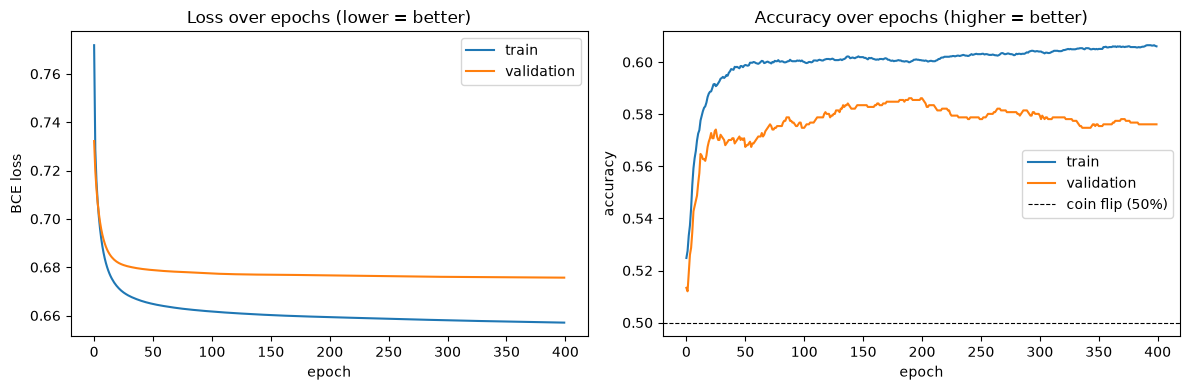

In [20]:
fig, ax = plt.subplots(1, 2, figsize=(12, 4))

ax[0].plot(history["train_loss"], label="train")
ax[0].plot(history["val_loss"], label="validation")
ax[0].set_title("Loss over epochs (lower = better)")
ax[0].set_xlabel("epoch"); ax[0].set_ylabel("BCE loss"); ax[0].legend()

ax[1].plot(history["train_acc"], label="train")
ax[1].plot(history["val_acc"], label="validation")
ax[1].axhline(0.5, color="black", linestyle="--", linewidth=0.8, label="coin flip (50%)")
ax[1].set_title("Accuracy over epochs (higher = better)")
ax[1].set_xlabel("epoch"); ax[1].set_ylabel("accuracy"); ax[1].legend()

plt.tight_layout()
plt.show()

## Step 13 — The honest evaluation: beat the baselines, then look at the test set

Accuracy alone is misleading. A model that always predicts "up" can look good if up-days are
common. So we compare the network against **dumb baselines** on the **test set** — the data
we have touched zero times until now.

- **Always up:** predict "up" every day. Accuracy = the fraction of up-days.
- **Coin flip:** 50% by definition.
- **Our network:** should beat both *if* it learned the planted momentum.

We also show a **confusion matrix**: a 2x2 table of predicted vs. actual, so we can see *how*
the model is right or wrong (e.g., does it over-predict "up"?).

In [21]:
# --- baselines ---
always_up_acc = max((y_test == 1).mean(), (y_test == 0).mean())

# --- our model on the untouched test set ---
test_p, _ = forward(params, X_test)
test_pred = (test_p > 0.5).astype(float)
model_acc = np.mean(test_pred == y_test)

print("===== TEST SET RESULTS (data the model never saw) =====")
print(f"Coin-flip baseline : 50.0%")
print(f"'Always up' baseline: {always_up_acc:.1%}")
print(f"Neural network     : {model_acc:.1%}")
print(f"\nEdge over 'always up': {model_acc - always_up_acc:+.1%}")

# --- confusion matrix (rows = actual, columns = predicted) ---
def confusion(y_true, y_pred):
    tp = int(np.sum((y_true == 1) & (y_pred == 1)))
    tn = int(np.sum((y_true == 0) & (y_pred == 0)))
    fp = int(np.sum((y_true == 0) & (y_pred == 1)))
    fn = int(np.sum((y_true == 1) & (y_pred == 0)))
    return tp, tn, fp, fn

tp, tn, fp, fn = confusion(y_test, test_pred)
print("\nConfusion matrix:")
print(f"                 predicted DOWN   predicted UP")
print(f"  actual DOWN          {tn:4d}            {fp:4d}")
print(f"  actual UP            {fn:4d}            {tp:4d}")

===== TEST SET RESULTS (data the model never saw) =====
Coin-flip baseline : 50.0%
'Always up' baseline: 51.4%
Neural network     : 60.0%

Edge over 'always up': +8.5%

Confusion matrix:
                 predicted DOWN   predicted UP
  actual DOWN           440             331
  actual UP             269             459


## Step 14 — A toy backtest (and why this is the hard part)

Classification accuracy is not money. A **backtest** simulates trading on the model's signals
to see the financial outcome. Our simple rule:

> Each test day, if the model predicts "up", hold the stock that day (capture its return).
> If it predicts "down", stay in cash (return 0). Compare the resulting equity curve to
> simply **buying and holding** the stock the whole time.

### Read this part skeptically
Even here, with a strong planted signal, treat any outperformance as a *demonstration of the
mechanics*, not a strategy. A real backtest must also account for:
- **Transaction costs & slippage** — trading every day eats returns fast.
- **The base rate / drift** — in an up-trending market, "buy and hold" is a tough benchmark.
- **One asset, one period** — no statistical significance.
- **Look-ahead and survivorship bias** — the classic ways backtests lie.

We compound `(1 + return)` each day to get the equity curves.

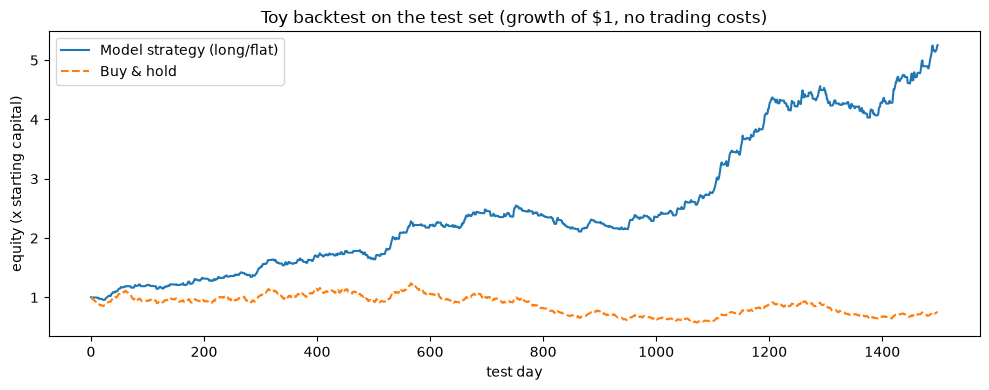

Model strategy final value : 5.252x
Buy & hold final value     : 0.753x

Remember: no transaction costs, synthetic data, single path. Demonstration only.


In [22]:
# Actual next-day returns aligned to the TEST examples.
# Recall example index t in the full arrays used returns[t] as the label-day return.
test_start = i_val + WINDOW                 # map test rows back to positions in `returns`
actual_test_returns = returns[test_start: test_start + len(y_test)]

position = test_pred[:, 0]                   # 1 = hold the stock that day, 0 = in cash
strategy_returns = position * actual_test_returns
buyhold_returns  = actual_test_returns

strategy_equity = np.cumprod(1 + strategy_returns)
buyhold_equity  = np.cumprod(1 + buyhold_returns)

plt.figure(figsize=(10, 4))
plt.plot(strategy_equity, label="Model strategy (long/flat)")
plt.plot(buyhold_equity,  label="Buy & hold", linestyle="--")
plt.title("Toy backtest on the test set (growth of $1, no trading costs)")
plt.xlabel("test day"); plt.ylabel("equity (x starting capital)")
plt.legend(); plt.tight_layout(); plt.show()

print(f"Model strategy final value : {strategy_equity[-1]:.3f}x")
print(f"Buy & hold final value     : {buyhold_equity[-1]:.3f}x")
print("\nRemember: no transaction costs, synthetic data, single path. Demonstration only.")

## Step 15 — The same network in PyTorch (optional)

You just built and trained a neural network by hand, computing every gradient yourself. A
**deep learning framework** like **PyTorch** automates two painful parts:

- **Autograd** — it computes all gradients for you (no hand-derived backprop).
- **Layers & optimizers** — prebuilt building blocks (`nn.Linear`, `Adam`, ...).

The model below is *the same architecture* (10 → 16 ReLU → 1). Notice you only write the
**forward pass**; PyTorch figures out the backward pass automatically. That is the main thing
a framework buys you, and why everyone uses one in practice.

> This cell is skipped automatically if PyTorch is not installed
> (`pip install torch` to enable it).

In [23]:
try:
    import torch
    import torch.nn as nn

    torch.manual_seed(SEED)

    # Convert our NumPy arrays into PyTorch tensors (its array type).
    Xtr = torch.tensor(X_train, dtype=torch.float32)
    ytr = torch.tensor(y_train, dtype=torch.float32)
    Xte = torch.tensor(X_test,  dtype=torch.float32)

    # Define the SAME architecture declaratively. nn.Sequential chains layers.
    model = nn.Sequential(
        nn.Linear(WINDOW, 16),   # the hidden layer's W1, b1 (10 -> 16)
        nn.ReLU(),               # the bend
        nn.Linear(16, 1),        # the output layer's W2, b2 (16 -> 1)
    )
    # BCEWithLogitsLoss = sigmoid + binary cross-entropy fused (numerically stable),
    # so the model outputs raw scores ("logits") and we apply sigmoid only for predictions.
    loss_fn   = nn.BCEWithLogitsLoss()
    optimizer = torch.optim.Adam(model.parameters(), lr=0.01)  # a smarter gradient descent

    for epoch in range(400):
        optimizer.zero_grad()          # clear old gradients
        logits = model(Xtr)            # forward pass (you only write THIS)
        loss   = loss_fn(logits, ytr)  # the loss
        loss.backward()                # autograd computes ALL gradients for you
        optimizer.step()               # update every parameter

    with torch.no_grad():                                  # no gradients needed for evaluation
        test_logits = model(Xte)
        test_prob   = torch.sigmoid(test_logits).numpy()   # logits -> probabilities
    pt_acc = np.mean((test_prob > 0.5).astype(float) == y_test)

    print(f"PyTorch model test accuracy : {pt_acc:.1%}")
    print(f"Our from-scratch model      : {model_acc:.1%}")
    print("Same idea, same ballpark result — the framework just wrote backprop for you.")

except ImportError:
    print("PyTorch not installed - skipping. (Optional: `pip install torch` to run this cell.)")

PyTorch model test accuracy : 57.9%
Our from-scratch model      : 60.0%
Same idea, same ballpark result — the framework just wrote backprop for you.


## Step 16 — What you learned, what we simplified, and the honest caveats

### What you actually built
A complete supervised deep-learning pipeline:
**data → features/labels (no leakage) → time-aware split → a neural network → forward pass →
loss → backpropagation → gradient descent → honest evaluation against baselines → a backtest.**
And you saw that PyTorch automates the calculus but changes none of the ideas.

### The vocabulary you now own
parameters/weights & biases · activation (ReLU, sigmoid) · layer · forward pass · loss
(binary cross-entropy) · gradient · backpropagation · gradient descent · learning rate ·
epoch · train/validation/test split · overfitting · baseline.

### What we deliberately simplified (your next steps to go deeper)
- **Full-batch gradient descent.** Real training uses **mini-batches** (a few examples at a
  time) — faster and often generalizes better.
- **One small hidden layer.** Add more/larger layers; try **dropout** or **weight decay** to
  fight overfitting.
- **A plain MLP on a window.** For sequences, **LSTMs** and **Transformers** are designed to
  model order and long-range dependence.
- **Predicting only direction.** You could predict the **return size** (regression) or model
  risk/volatility.
- **No hyperparameter search.** Learning rate, hidden size, window length, and epochs all
  matter and are usually tuned on the validation set.

### The essential honesty about financial ML
- **Our data was synthetic with an unrealistically strong, planted pattern.** That is why the
  model worked. It is a teaching aid.
- **Real markets are close to efficient.** Predicting next-day direction from past prices
  alone is near-impossible; live edges are tiny, fleeting, and competed away.
- **A good backtest is not a profitable strategy.** Costs, slippage, capacity, regime change,
  and overfitting to history routinely turn "great backtests" into real-world losses.
- **This notebook is educational, not investment advice.** Do not trade real money on it.

You now understand, from the ground up, what deep learning *is*: a function with adjustable
knobs, tuned by repeatedly nudging them to reduce a single error number. Everything
else — bigger models, fancier layers, more data — is elaboration on that one idea.